# Worksheet: Introduction to CNNs

**Topic:** Introduction to Convolutional Neural Networks (CNNs)

## Learning goals

By the end of this worksheet, students should be able to:

1. Explain how images are represented as tensors.
2. Explain why ordinary feed-forward networks are not ideal for images.
3. Describe what a convolution kernel/filter does.
4. Compute simple convolution outputs by hand.
5. Compute output shapes after convolution and pooling.
6. Explain the role of stride and pooling.
7. Build a simple CNN in Keras.
8. Connect CNNs to business applications such as image classification and visual inspection.

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---

# 1. Image representation

Images are represented by arrays of numbers.

- A **grayscale image** can be represented as a matrix. We have 1 single channel represented as a grayscale. E.g., 3000 x 2000 (3000 rows by 2000 columns). 4K resolution is is 3840 x 2160. In NNs you want a tuple (3840, 2160) as input shape. We can represent as tensors, e.g., (3840, 2160, 1) as input shape in network requires a 3-way tensor.
- A **color image** can be represented as a tensor with 3 channels:
  - Red
  - Green
  - Blue

  Example, 4k color image (3840, 2160, 3)

So a color image with height `H` and width `W` has shape:

`(H, W, 3)`

## Practice 1A: Shapes

Answer the following:

1. What is the shape of a grayscale image with 28 rows and 28 columns?
2. What is the shape of a color image with height 64 and width 64?
3. What does the `3` represent in `(64, 64, 3)`?

**Your response here:**  
1.  (28,28) or (28,28,1): 784 x 1 flattened.
2.  (64, 64, 3): 12288 x 1 flattened
3.  Represents the channels

**Flattening an Image**



In [3]:
import tensorflow as tf

# load the data
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# standardize: because each pixel has a minimum of 0 and a max of 255, we usually standardize images as:
X_train, X_test = X_train/255, X_test/255  ## (0,1) is the most common in images

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
X_train.shape

## every image is a matrix of size (28x28)
## we have 60000 images in training
## if NN requires a tensor X_train.reshape((60000, 28,28,1))

(60000, 28, 28)

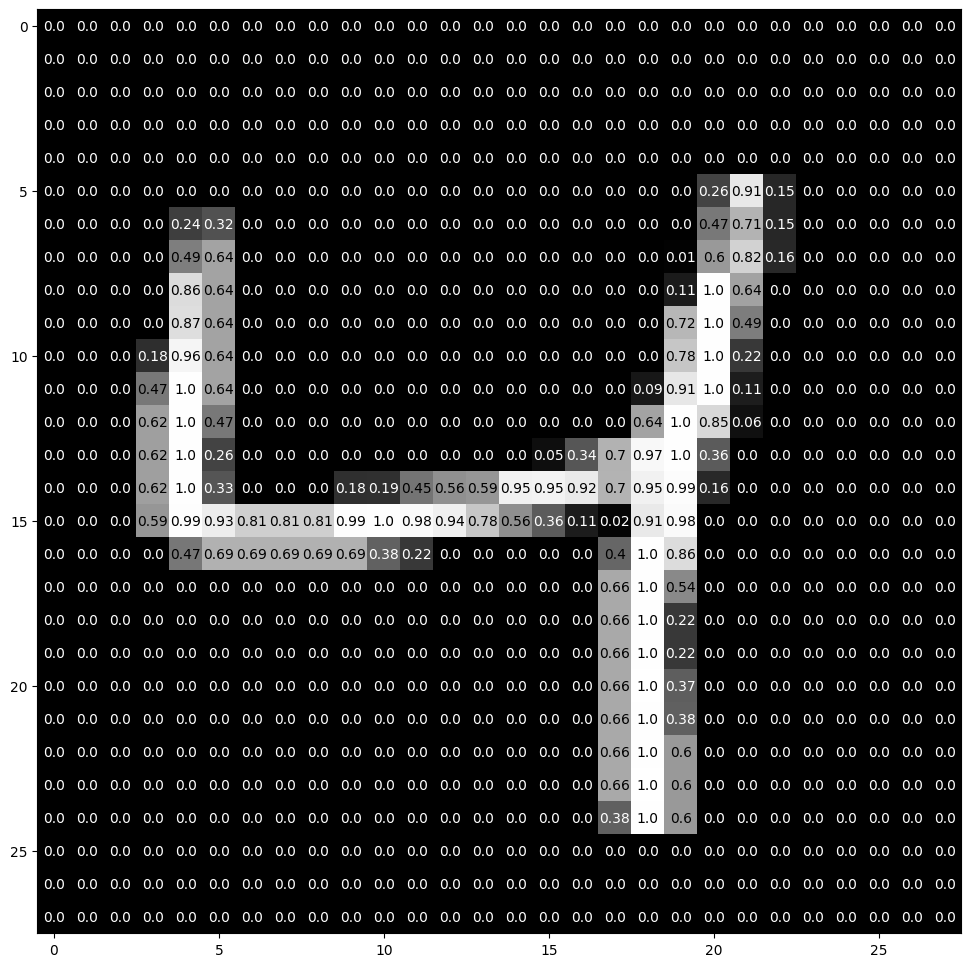

In [5]:
# see standardization example below:
import matplotlib.pyplot as plt

def visualize_input(img, ax):
    ax.imshow(img, cmap='gray')
    width, height = img.shape
    thresh = img.max()/2.5
    for x in range(width):
        for y in range(height):
            ax.annotate(str(round(img[x][y],2)), xy=(y,x),
                        horizontalalignment='center',
                        verticalalignment='center',
                        color='white' if img[x][y]<thresh else 'black')

fig = plt.figure(figsize = (12,12))
ax = fig.add_subplot(111)

## plot figure 3
visualize_input(X_train[2].reshape(28,28), ax)

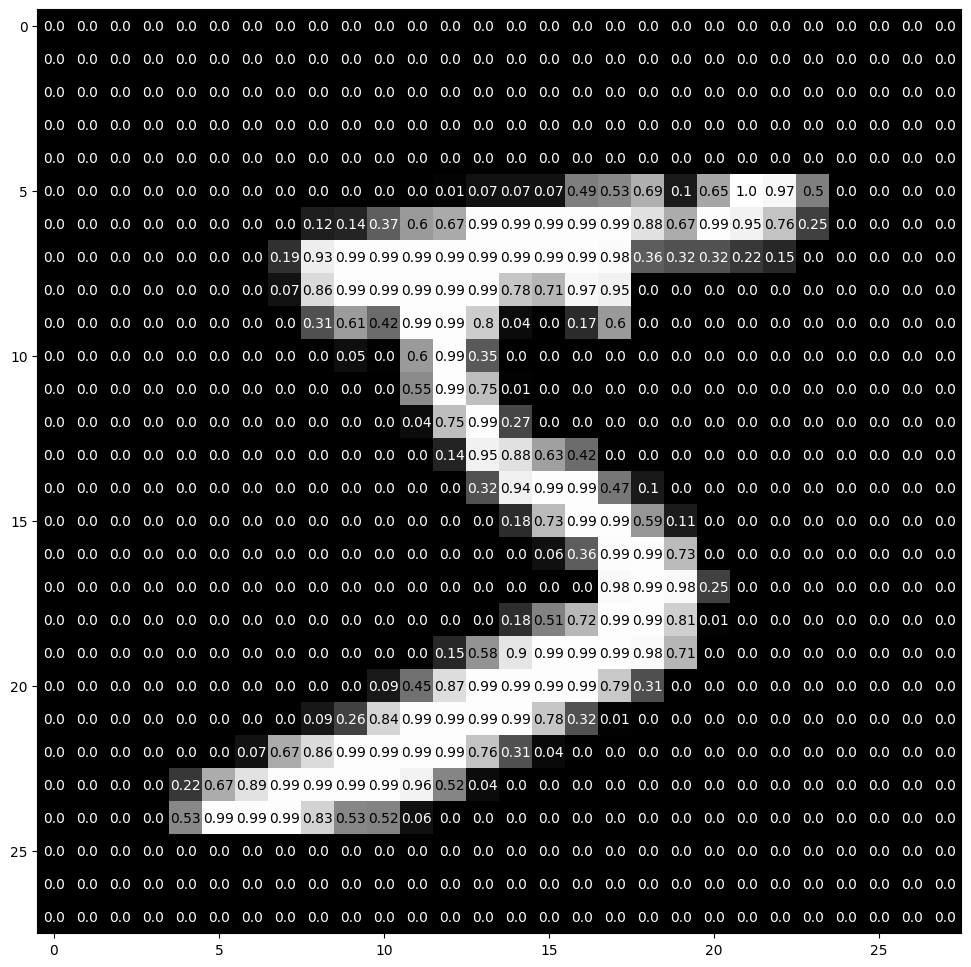

In [6]:
## plot figure 1
fig = plt.figure(figsize = (12,12))
ax = fig.add_subplot(111)

## plot figure1
visualize_input(X_train[0].reshape(28,28), ax)


**Fitting NN**

Fit the following neural networ:


Input - Hidden 1 (128, 'relu') - Dropout (20%) - Output Layer (10 digits)

In [7]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [8]:
## fit a feed-forward architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input

model = Sequential()
model.add(Input(shape=(28,28)))  ## input size (28,28)
model.add(Flatten())            ## flattened size 784
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

## model summary
model.summary()

## compile
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy")  ## because we have label encoding (3,5,7, ....)

## early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(patience=3, restore_best_weights=True)

## fit
model.fit(X_train, y_train, epochs = 200, validation_split = 0.2, callbacks=[early_stopping])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3299 - val_loss: 0.1604
Epoch 2/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1593 - val_loss: 0.1211
Epoch 3/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1168 - val_loss: 0.0994
Epoch 4/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0967 - val_loss: 0.0907
Epoch 5/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0810 - val_loss: 0.0844
Epoch 6/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0707 - val_loss: 0.0840
Epoch 7/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0620 - val_loss: 0.0791
Epoch 8/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0534 - val_loss: 0.0777
Epoch 9/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0509 - val_loss: 0.0817
Epoch 10/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0445 - val_loss: 0.0820
Epoch 11/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0415 - val_loss: 0.0829


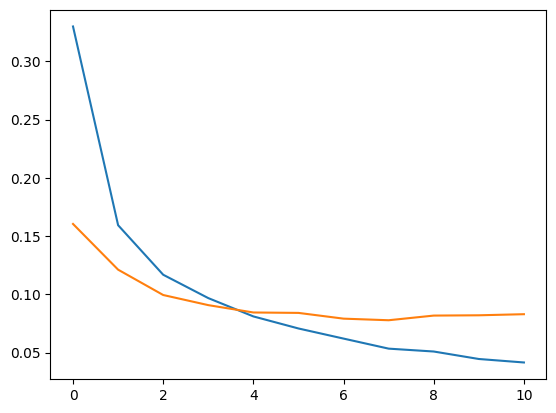

In [9]:
## plot learning curve

plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step


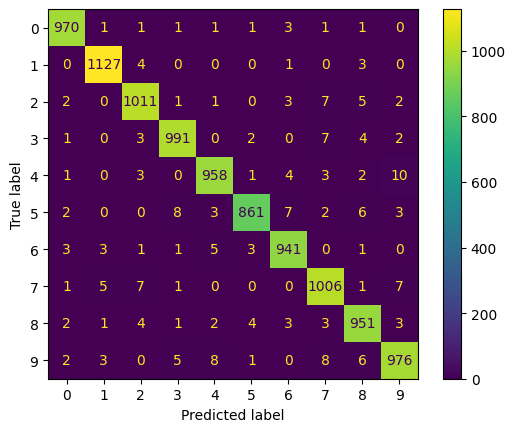

In [10]:
## performance (Confusion matrix)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [11]:
# load the data
import tensorflow as tf
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# standardize: because each pixel has a minimum of 0 and a max of 255, we usually standardize images as:
X_train, X_test = X_train/255, X_test/255

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


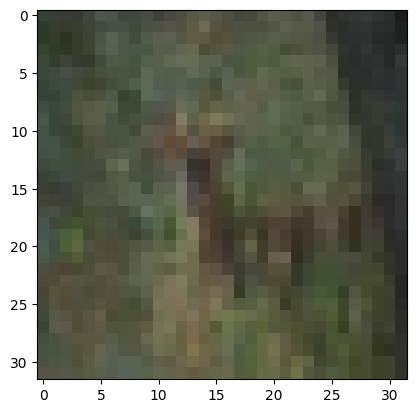

In [12]:
import matplotlib.pyplot as plt
plt.imshow(X_train[10],cmap=plt.cm.binary)

In [13]:
## each image is a tensor of size (32, 32, 3)
## flattened: 3072
X_train.shape

(50000, 32, 32, 3)

**Fit the network below**

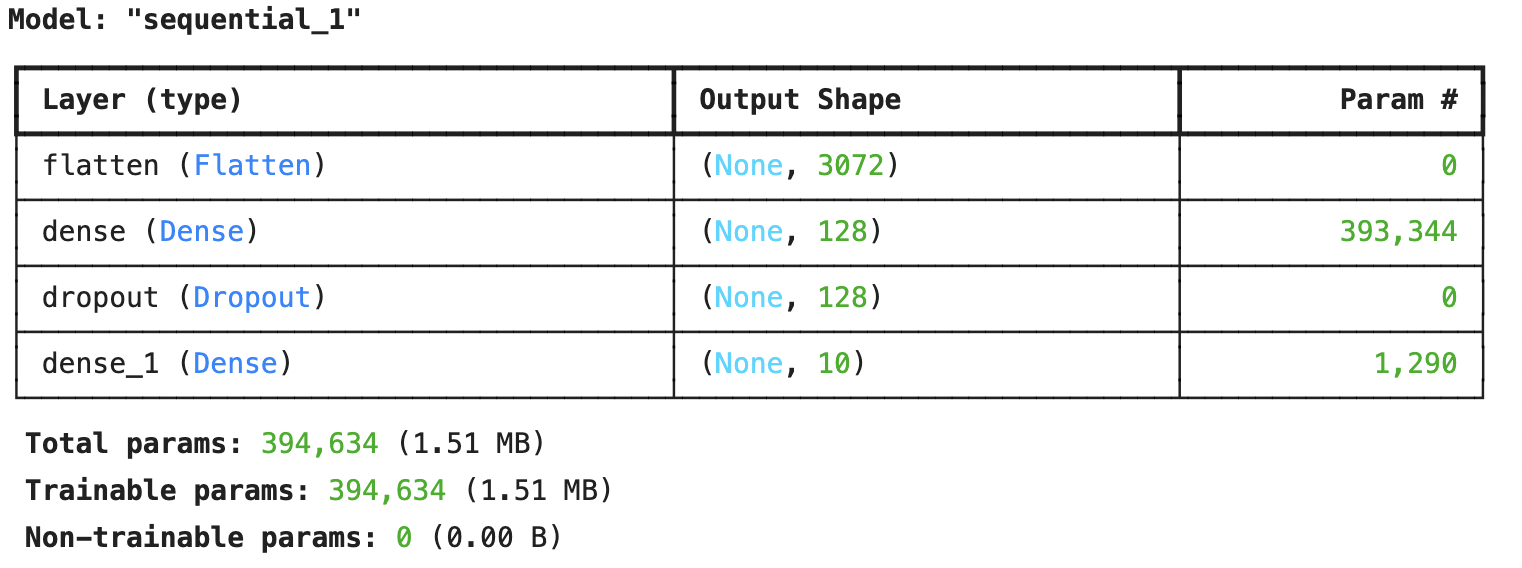

In [14]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [15]:
## Color image example
## feed-forward
nn = Sequential()
nn.add(Input(shape = (32,32,3)))
nn.add(Flatten())  ## flattened to 3072 variables
nn.add(Dense(128, activation = "relu"))
nn.add(Dropout(0.2))
nn.add(Dense(10, activation = "softmax"))

## summary
nn.summary()

## compile
nn.compile(loss = "sparse_categorical_crossentropy",
           optimizer = "adam",
           metrics = ["accuracy"])

## Early Stopping
es = EarlyStopping(monitor = "val_loss", patience = 5, restore_best_weights = True)

## fit
nn.fit(X_train, y_train, validation_split = 0.2, epochs = 100, callbacks = [es])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1928 - loss: 2.1304 - val_accuracy: 0.2765 - val_loss: 1.9689
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2509 - loss: 2.0120 - val_accuracy: 0.2868 - val_loss: 1.9410
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2689 - loss: 1.9735 - val_accuracy: 0.3070 - val_loss: 1.9007
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2817 - loss: 1.9543 - val_accuracy: 0.3246 - val_loss: 1.8731
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2905 - loss: 1.9393 - val_accuracy: 0.3339 - val_loss: 1.8629
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2898 - loss: 1.9358 - val_accuracy: 0.3376 - val_loss: 1.8574
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.2926 - loss: 1.9292 - val_accuracy: 0.3456 - val_loss: 1.8462
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.2971 - loss: 1

## Practice 1B: Why not just flatten in every problem?

A 64 × 64 color image could be flattened into one long vector.

Why might this be a problem for a standard feed-forward neural network?

**Your response here:**  

The feed-forward NN is over-parameterized (too many parameters). Very slow. Does not perform as well.



---

# 2. Why CNNs?

Feed-forward neural networks are usually not ideal for images because:

- flattening creates **many parameters**
- they ignore **spatial structure**
- they do not naturally handle **translation invariance**

CNNs help by using:
- local filters
- shared weights
- pooling

## Practice 2A: Concept check

Fill in the blanks:

1. CNNs preserve the _____ structure of images.
2. A small matrix that slides over an image is called a _____ or _____.
3. Pooling is often used to _____ the image representation.

**Your answers here:**  
1.  Structure (invariance)
2.  Convolution (filter, kernel)
3.  Downsize an image

---

# 3. A convolution by hand

A **convolution** uses a small matrix called a kernel or filter.

The kernel slides across the image, multiplies overlapping values, and sums them to produce one output value.

In [16]:

# Example 4x4 image
image = np.array([
    [1, 2, 0, 1],
    [3, 1, 2, 2],
    [0, 1, 3, 1],
    [2, 2, 1, 0]
])

# Example 2x2 kernel
kernel = np.array([
    [1, 0],
    [0, 1]
])

print("Image:\n", image)
print("\nKernel:\n", kernel)

Image:
 [[1 2 0 1]
 [3 1 2 2]
 [0 1 3 1]
 [2 2 1 0]]

Kernel:
 [[1 0]
 [0 1]]


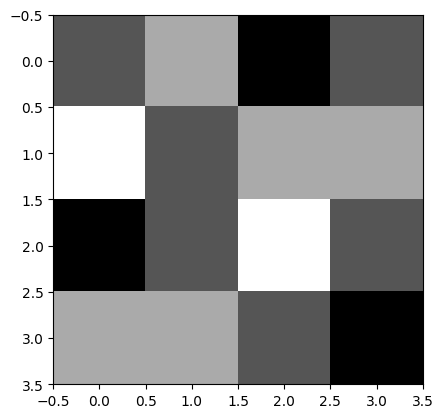

In [17]:
import matplotlib.pyplot as plt

plt.imshow(image, cmap="gray")
plt.show()

## Practice 3A: First convolution output

Using stride = 1 and no padding, compute the **top-left** output value.

Use this 2×2 patch from the image:

$
\begin{bmatrix}
1 & 2 \\
3 & 1
\end{bmatrix}
$

and the kernel:

$
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$

Multiply elementwise and sum.

In [18]:
## the resulting image will be 4 - 2 + 1 (3 rows)
## the resulting image will be 4 - 2 + 1 (3 cols)
## top left

# TODO
top_left_value = 1*1 + 2*0 + 3*0 +  1*1
print("Top-left output value =", top_left_value)

Top-left output value = 2


## Practice 3B: Compute the full convolution output

Write code to compute the full 2D convolution output for this example, using:
- no padding
- stride = 1

In [19]:
## computes the whole convolution
## this is a convolution neuron
## called Conv2D (for 2-dimensional images)
## Conv3D (would be for movies)

def Convolution2D(image, kernel):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Extract the patch from the image
            patch = image[i:i + kernel_height, j:j + kernel_width]
            # Perform element-wise multiplication and sum
            output[i, j] = np.sum(patch * kernel)

    return output

In [20]:
# TODO
output = Convolution2D(image, kernel)
print(output)

[[2. 4. 2.]
 [4. 4. 3.]
 [2. 2. 3.]]


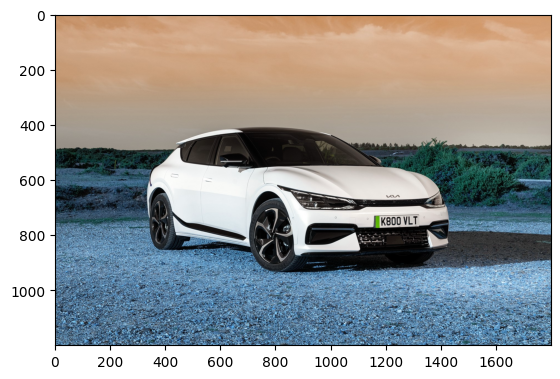

In [22]:
import cv2

## read image
car_color = cv2.imread('car_image.jpeg')

## plot
plt.imshow(car_color)
plt.show()

In [23]:
car_color.shape

(1200, 1800, 3)

In [24]:
car_gray = cv2.cvtColor(car_color, cv2.COLOR_BGR2GRAY)

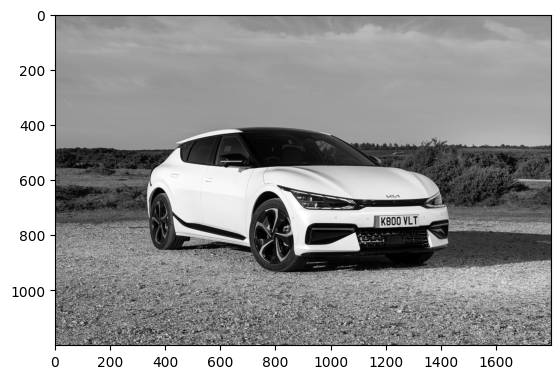

In [25]:
## plot
plt.imshow(car_gray, cmap = "gray")
plt.show()

---

# 4. Output shape formulas

For a 2D convolution, the output dimension (for both rows and cols) is often computed as:


`input_size - filter_size + 1`


## Practice 4A: Compute output size

Suppose:
- input size = 28 x 28
- filter size = 3 x 3

Compute the output size (rows).

In [40]:
# TODO
output_size = 28 - 3 + 1
print("Output size =", output_size)

Output size = 26


## Practice 4B: Another shape example

Suppose:
- input size = 32x32
- filter size = 5x5

Compute the output size (cols).

In [41]:
# TODO
output_size_2 = 32 - 5 + 1
print("Output size =", output_size_2)

Output size = 28


---

# 5. Stride

The **stride** tells us how far the kernel moves each time.

- stride = 1 means move one step at a time
- stride = 2 means skip more positions and produce a smaller output

---

# 6. Pooling

Pooling is used to downsample feature maps while keeping important information.

Common types:
- **Max pooling**
- **Average pooling**

In [31]:

feature_map = np.array([
    [1, 3, 2, 0],
    [4, 6, 5, 1],
    [0, 2, 8, 7],
    [1, 3, 4, 2]
])

print(feature_map)

[[1 3 2 0]
 [4 6 5 1]
 [0 2 8 7]
 [1 3 4 2]]


## Practice 6A: Max pooling by hand

Using a 2×2 pooling window, compute the pooled output of the first element [0,0] using **max pooling**.

In [32]:
# TODO
max_pooled = feature_map[0:2, 0:2].max()
print(max_pooled)

6


In [47]:
def max_pooling(image, pool_size=(2, 2), stride=1):
    map_height, map_width = image.shape
    pool_height, pool_width = pool_size

    output_height = (map_height - pool_height) // stride + 1
    output_width = (map_width - pool_width) // stride + 1

    pooled_output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # FIXED: Extract the pooling window from 'image', not 'feature_map'
            window = image[i * stride : i * stride + pool_height,
                           j * stride : j * stride + pool_width]
            # Apply max pooling
            pooled_output[i, j] = np.max(window)

    return pooled_output

In [43]:
max_pooling(feature_map)

array([[6., 6., 5.],
       [6., 8., 8.],
       [3., 8., 8.]])

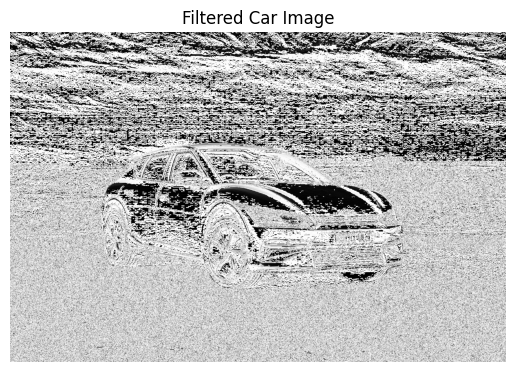

In [50]:
mp_car = max_pooling(filter_car)

mp_car = mp_car.astype(np.uint8)

plt.imshow(mp_car, cmap='gray')
plt.title('Filtered Car Image')
plt.axis('off')
plt.show()

## Practice 6B: Average pooling

Now compute the pooled output [0,0] using **average pooling** with the same 2×2 window.

In [51]:
# TODO
avg_pooled = feature_map[0:2, 0:2].mean()
print(avg_pooled)

3.5


In [52]:
def average_pooling(feature_map, pool_size=(2, 2), stride=1):
    map_height, map_width = feature_map.shape
    pool_height, pool_width = pool_size

    output_height = (map_height - pool_height) // stride + 1
    output_width = (map_width - pool_width) // stride + 1

    pooled_output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Extract the pooling window
            window = feature_map[i * stride : i * stride + pool_height,
                                   j * stride : j * stride + pool_width]
            # Apply average pooling
            pooled_output[i, j] = np.mean(window)

    return pooled_output

## Practice 6C: Interpretation

Why might max pooling be useful in image tasks?

**Your response here:**  




---

# 7. Multiple filters and feature maps

A CNN does not usually use just one filter.

If we apply multiple filters to the same image, we get multiple output feature maps.
That is why convolutional layers can learn many different visual patterns:
- edges
- corners
- textures
- shapes

## Practice 7A: Concept check

If one convolutional layer uses 16 filters, how many output feature maps does it produce?

In [54]:

# TODO
num_feature_maps = 16
print("Number of feature maps =", num_feature_maps)

Number of feature maps = 16


---

# 8. Business context for CNNs

CNNs are useful in business whenever the input has image-like structure.

Examples:
- product image classification
- defect detection in manufacturing
- medical image screening
- document and invoice processing
- retail shelf image recognition

## Practice 8A: Business application

Choose one business application of CNNs and explain:
1. what the input image could be
2. what the model might predict

**Your response here:**  
1.  
2.

---

# 9. Why CNNs usually outperform dense networks on images

A CNN usually has fewer parameters than a fully connected network on raw image pixels because:
- filters are small
- weights are shared
- the model focuses on local patterns first

---

# 11. Quiz-style review

Complete the following:

### Review 1
What is the difference between a grayscale image and a color image in terms of array shape?

### Review 2
What does a convolution filter do?

### Review 3
What does pooling do?

### Review 4
If a layer uses 32 filters, how many feature maps are produced?

### Review 5
Why are CNNs often better than ordinary feed-forward networks for image tasks?

**Your responses here:**  
1.  
2.  
3.  
4.  
5.

## Quick self-check

Suggested answers:
- grayscale is 2D, color usually has 3 channels
- it slides across the image to create a new feature map
- it downsamples while keeping important information
- 32
- CNNs preserve spatial structure and use shared filters